In [2]:
import pandas as pd

df=pd.read_csv('ford.csv')

print(df.head())

     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0


In [3]:
print("Shape: ",df.shape)
print("Info: ",df.info)
print("Is null: ",df.isnull().sum())
print("Describle: ",df.describe())

Shape:  (17966, 9)
Info:  <bound method DataFrame.info of          model  year  price transmission  ...  fuelType  tax   mpg  engineSize
0       Fiesta  2017  12000    Automatic  ...    Petrol  150  57.7         1.0
1        Focus  2018  14000       Manual  ...    Petrol  150  57.7         1.0
2        Focus  2017  13000       Manual  ...    Petrol  150  57.7         1.0
3       Fiesta  2019  17500       Manual  ...    Petrol  145  40.3         1.5
4       Fiesta  2019  16500    Automatic  ...    Petrol  145  48.7         1.0
...        ...   ...    ...          ...  ...       ...  ...   ...         ...
17961    B-MAX  2017   8999       Manual  ...    Petrol  150  47.1         1.4
17962    B-MAX  2014   7499       Manual  ...    Petrol   30  57.7         1.0
17963    Focus  2015   9999       Manual  ...    Diesel   20  67.3         1.6
17964       KA  2018   8299       Manual  ...    Petrol  145  57.7         1.2
17965    Focus  2015   8299       Manual  ...    Petrol   22  57.7       

In [4]:
df=pd.get_dummies(
    df,drop_first=True
)
print(df.head())

   year  price  mileage  ...  fuelType_Hybrid  fuelType_Other  fuelType_Petrol
0  2017  12000    15944  ...            False           False             True
1  2018  14000     9083  ...            False           False             True
2  2017  13000    12456  ...            False           False             True
3  2019  17500    10460  ...            False           False             True
4  2019  16500     1482  ...            False           False             True

[5 rows x 35 columns]


In [5]:
X=df.drop('price',axis=1)
y=df['price']

print("X shape: ",X.shape)
print("y shape: ",y.shape)

X shape:  (17966, 34)
y shape:  (17966,)


In [6]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=43,test_size=0.2
)


In [7]:
from sklearn.ensemble import RandomForestRegressor

model=RandomForestRegressor(
    n_estimators=100,random_state=42

)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [8]:
y_pred=model.predict(X_test)

print(y_pred[:10])

[ 8187.29 16415.69 17765.55 22836.67 25217.78  8736.85 12889.28 18012.86
 10522.62  6785.88]


In [9]:
from sklearn.metrics import (
    mean_absolute_error,mean_squared_error,r2_score
)

mae=mean_absolute_error(y_test,y_pred)

mse=mean_squared_error(y_test,y_pred)

r2=r2_score(y_test,y_pred)

print("MAE: ",mae )
print("MSE: ",mse)
print("R2 Score: ",r2)

MAE:  875.1137077216436
MSE:  1673801.32989949
R2 Score:  0.9290011555852175


In [10]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

   Actual  Predicted
0    8695    8187.29
1   17280   16415.69
2   16495   17765.55
3   22999   22836.67
4   25500   25217.78
5    8650    8736.85
6   16990   12889.28
7   17500   18012.86
8   10498   10522.62
9    6645    6785.88


In [11]:
print("Training Score: ",model.score(X_train,y_train))
print("Testing Score: ",model.score(X_test,y_test))

Training Score:  0.9896274283871379
Testing Score:  0.9290011555852175


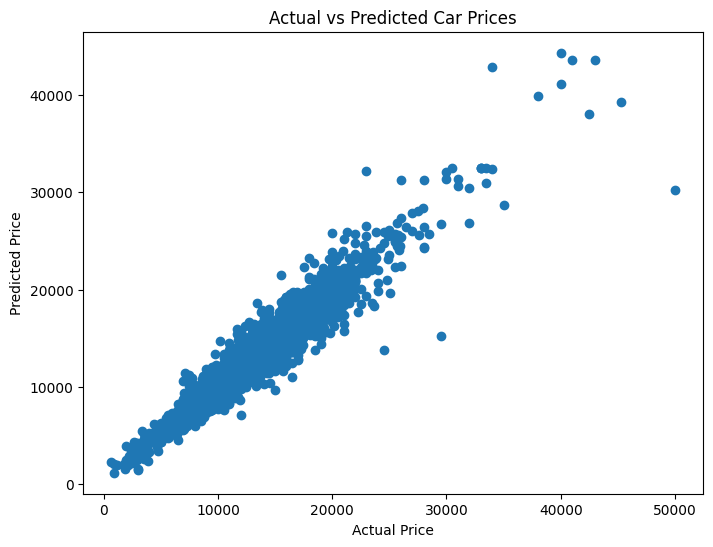

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

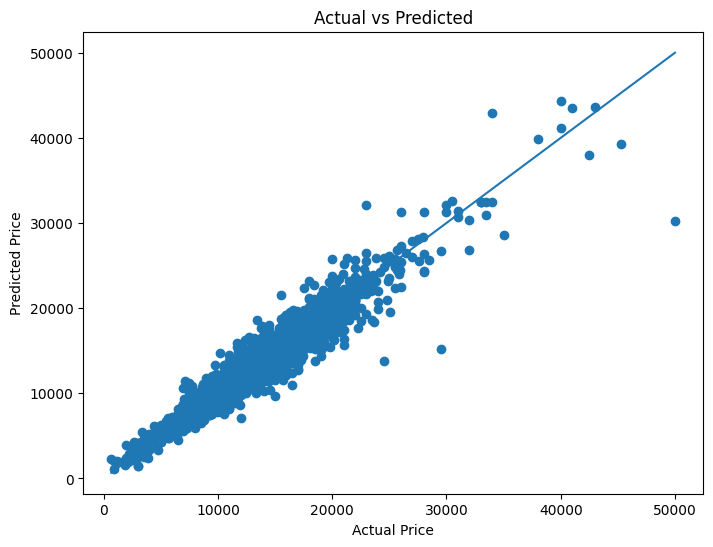

In [13]:
plt.figure(figsize=(8,6))

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [14]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

           Feature  Importance
0             year    0.489817
4       engineSize    0.238950
1          mileage    0.072746
3              mpg    0.067740
17     model_ Kuga    0.029951
9    model_ Fiesta    0.019568
16      model_ Ka+    0.018571
19  model_ Mustang    0.009997
7      model_ Edge    0.008178
2              tax    0.007540


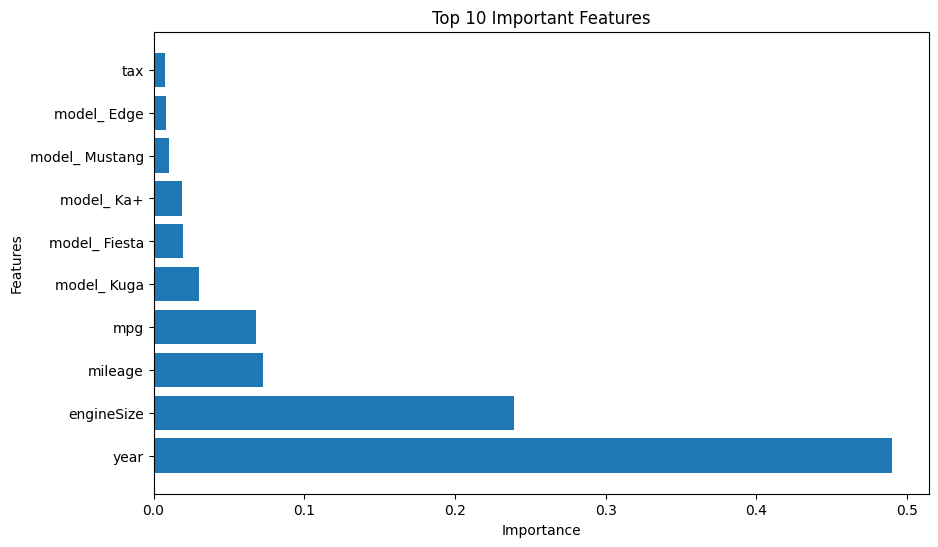

In [15]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Top 10 Important Features")

plt.show()